In [12]:
# Install required packages
!pip install transformers datasets torch matplotlib seaborn

In [13]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter
from datasets import load_dataset
from transformers import AutoTokenizer
from torch.utils.data import DataLoader

torch.manual_seed(42)
np.random.seed(42)

In [14]:
# 1. Load WikiText-2 raw dataset — a Wikipedia-based corpus for language modeling
dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="train")
val_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="validation")
test_dataset = load_dataset("wikitext", "wikitext-2-raw-v1", split="test")

print(f"Training split  : {len(dataset)}")
print(f"Validation split: {len(val_dataset)}")
print(f"Test split      : {len(test_dataset)}")

Training split  : 36718
Validation split: 3760
Test split      : 4358


Non-empty lines: 23767 / 36718 (64.7%)
Avg text length : 458.3 chars
Median          : 401 chars


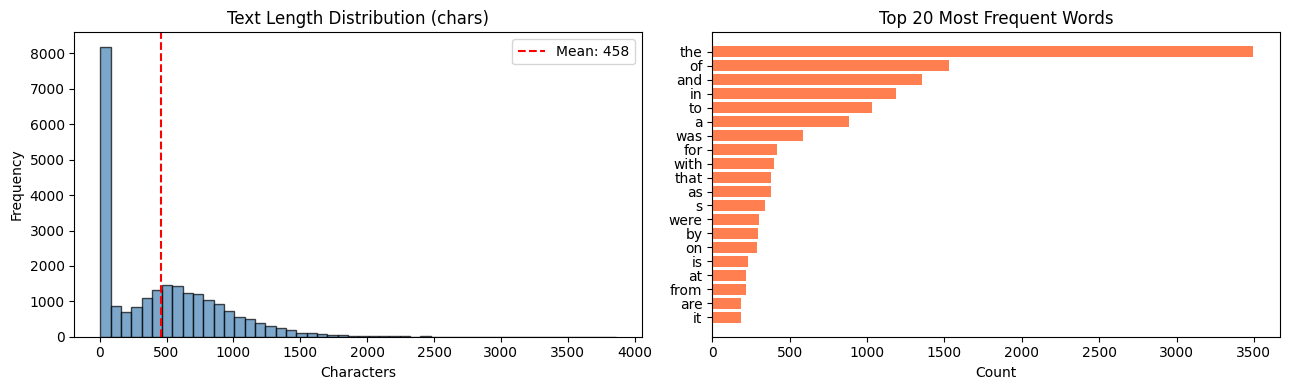

In [15]:
# 2. Quick dataset exploration — check for empty lines and text length distribution
texts = [item["text"] for item in dataset]
non_empty = [t for t in texts if t.strip()]
lengths = [len(t) for t in non_empty]

print(f"Non-empty lines: {len(non_empty)} / {len(texts)} ({len(non_empty)/len(texts)*100:.1f}%)")
print(f"Avg text length : {np.mean(lengths):.1f} chars")
print(f"Median          : {np.median(lengths):.0f} chars")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(lengths, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].axvline(np.mean(lengths), color='red', linestyle='--', label=f'Mean: {np.mean(lengths):.0f}')
axes[0].set_title('Text Length Distribution (chars)')
axes[0].set_xlabel('Characters')
axes[0].set_ylabel('Frequency')
axes[0].legend()

word_counts = Counter()
for t in texts[:1000]:
    word_counts.update(re.findall(r'\b\w+\b', t.lower()))

top_words = word_counts.most_common(20)
words, counts = zip(*top_words)
axes[1].barh(words[::-1], counts[::-1], color='coral')
axes[1].set_title('Top 20 Most Frequent Words')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

In [16]:
# 3. Initialize GPT-2 BPE tokenizer and set pad token
tokenizer = AutoTokenizer.from_pretrained("gpt2")
tokenizer.pad_token = tokenizer.eos_token  # GPT-2 has no default pad token

print(f"Vocab size: {tokenizer.vocab_size}")
print(f"Pad token : '{tokenizer.pad_token}' (id={tokenizer.pad_token_id})")

example = "Transformers use self-attention for sequence modeling."
enc = tokenizer(example)
print(f"\nExample: '{example}'")
print(f"Tokens : {tokenizer.convert_ids_to_tokens(enc['input_ids'])}")
print(f"IDs    : {enc['input_ids']}")

Vocab size: 50257
Pad token : '<|endoftext|>' (id=50256)

Example: 'Transformers use self-attention for sequence modeling.'
Tokens : ['Transform', 'ers', 'Ġuse', 'Ġself', '-', 'att', 'ention', 'Ġfor', 'Ġsequence', 'Ġmodeling', '.']
IDs    : [41762, 364, 779, 2116, 12, 1078, 1463, 329, 8379, 21128, 13]


In [17]:
# 4. Tokenize the entire dataset using batched .map() for efficiency
def tokenize_function(examples):
    """Tokenize raw text without special token masking."""
    return tokenizer(examples["text"], return_special_tokens_mask=False)

tokenized_ds = dataset.map(tokenize_function, batched=True, remove_columns=["text"])

print(f"Columns: {tokenized_ds.column_names}")
for i in range(min(10, len(tokenized_ds))):
    if len(tokenized_ds[i]['input_ids']) > 0:
        print(f"Example {i} tokens (first 20): {tokenized_ds[i]['input_ids'][:20]}")
        print(f"Decoded: '{tokenizer.decode(tokenized_ds[i]['input_ids'][:20])}'")
        break

Columns: ['input_ids', 'attention_mask']
Example 1 tokens (first 20): [796, 569, 18354, 7496, 17740, 6711, 796, 220, 198]
Decoded: ' = Valkyria Chronicles III = 
'


Total tokens in corpus : 2,391,884
Unique tokens used     : 36,997
Vocab coverage         : 73.6%

Top 10 tokens:
      ' the'  →  113,190
        ' ,'  →  99,913
        ' .'  →  73,416
       ' of'  →  56,891
      ' and'  →  50,607
       ' in'  →  39,602
       ' to'  →  39,233
        ' a'  →  34,414
        ' ='  →  29,570
        ' "'  →  28,309


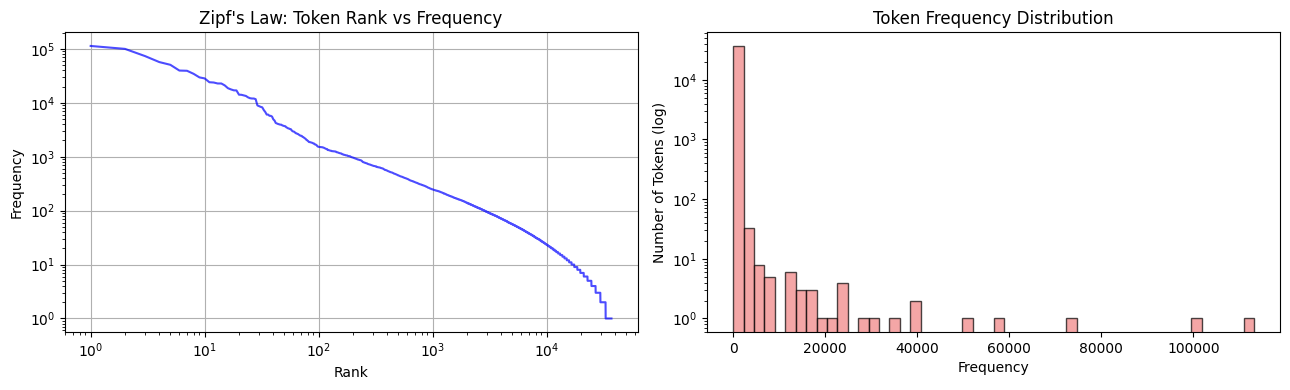

In [18]:
# 5. Token frequency analysis & visualization
all_token_ids = [tid for item in tokenized_ds for tid in item['input_ids']]
token_freq = Counter(all_token_ids)

print(f"Total tokens in corpus : {len(all_token_ids):,}")
print(f"Unique tokens used     : {len(token_freq):,}")
print(f"Vocab coverage         : {len(token_freq)/tokenizer.vocab_size*100:.1f}%")

print("\nTop 10 tokens:")
for tid, cnt in token_freq.most_common(10):
    print(f"  {repr(tokenizer.decode([tid])):>10s}  →  {cnt:,}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sorted_freqs = sorted(token_freq.values(), reverse=True)
axes[0].loglog(range(1, len(sorted_freqs)+1), sorted_freqs, 'b-', alpha=0.7)
axes[0].set_title("Zipf's Law: Token Rank vs Frequency")
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')
axes[0].grid(True)

axes[1].hist(sorted_freqs, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
axes[1].set_yscale('log')
axes[1].set_title('Token Frequency Distribution')
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Number of Tokens (log)')

plt.tight_layout()
plt.show()

In [19]:
# 6. Concatenate all tokens and split into fixed-length sequences for LM training
block_size = 128

def group_texts(examples):
    """Flatten token streams and carve into non-overlapping blocks."""
    concatenated_inputs = sum(examples["input_ids"], [])
    concatenated_masks = sum(examples["attention_mask"], [])

    total_len = (len(concatenated_inputs) // block_size) * block_size
    concatenated_inputs = concatenated_inputs[:total_len]
    concatenated_masks = concatenated_masks[:total_len]

    result_input_ids = [concatenated_inputs[i:i+block_size] for i in range(0, total_len, block_size)]
    result_masks = [concatenated_masks[i:i+block_size] for i in range(0, total_len, block_size)]

    return {"input_ids": result_input_ids, "attention_mask": result_masks}


lm_ds = tokenized_ds.map(group_texts, batched=True, batch_size=1000)
print(f"LM training sequences: {len(lm_ds)} (each {block_size} tokens)")
print(f"Total training tokens: {len(lm_ds) * block_size:,}")

LM training sequences: 18667 (each 128 tokens)
Total training tokens: 2,389,376


In [20]:
# 7. Create DataLoader with custom collate function
batch_size = 8

def collate_fn(batch):
    """Stack fixed-length sequences into a batch tensor."""
    input_ids = torch.tensor([example["input_ids"] for example in batch], dtype=torch.long)
    return {"input_ids": input_ids, "labels": input_ids.clone()}

train_loader = DataLoader(
    lm_ds,
    batch_size=batch_size,
    shuffle=True,
    collate_fn=collate_fn,
    drop_last=True
)

print(f"Batch size      : {batch_size}")
print(f"Batches / epoch : {len(train_loader)}")

Batch size      : 8
Batches / epoch : 2333


In [21]:
# 8. Validate the DataLoader — check shapes, types and decode a sample
for i, batch in enumerate(train_loader):
    print(f"Batch {i+1}:")
    print(f"  input_ids shape : {batch['input_ids'].shape}")
    print(f"  labels shape    : {batch['labels'].shape}")
    print(f"  dtype           : {batch['input_ids'].dtype}")

    decoded = tokenizer.decode(batch['input_ids'][0][:25])
    print(f"  Decoded (first 25 tokens): '{decoded}'")

    assert batch['input_ids'].shape == (batch_size, block_size), "Shape mismatch!"
    break

print(f"\nPipeline ready — {len(lm_ds):,} sequences, {len(lm_ds)*block_size:,} tokens total.")

Batch 1:
  input_ids shape : torch.Size([8, 128])
  labels shape    : torch.Size([8, 128])
  dtype           : torch.int64
  Decoded (first 25 tokens): ' acid may cause the breakdown of significant numbers of red blood cells . 
 = = = Electrical = = = 
 Electrical'

Pipeline ready — 18,667 sequences, 2,389,376 tokens total.
